Dataset

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/gscdit/Breast-Cancer-Detection/refs/heads/master/data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
df.drop(columns=['id', 'Unnamed: 32'],inplace=True)

In [5]:
df.shape

(569, 31)

In [6]:
X_train,X_test,y_train,y_test = train_test_split(df.iloc[:, 1:], df.iloc[:, 0], test_size=0.2)

In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

In [9]:
X_train_tensor = torch.from_numpy(X_train).float()
X_test_tensor = torch.from_numpy(X_test).float()
y_train_tensor = torch.from_numpy(y_train).float()
y_test_tensor = torch.from_numpy(y_test).float()
print(X_train_tensor.shape, X_test_tensor.shape, y_train_tensor.shape, y_test_tensor.shape)

torch.Size([455, 30]) torch.Size([114, 30]) torch.Size([455]) torch.Size([114])


In [10]:
from torch.utils.data import Dataset, DataLoader

class CustomDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        return self.features[index], self.labels[index]

In [11]:
train_dataset = CustomDataset(X_train_tensor, y_train_tensor)
test_dataset = CustomDataset(X_test_tensor, y_test_tensor)

In [12]:
train_dataset[10]

(tensor([-1.0910, -1.0564, -1.0527, -0.9359,  0.1934, -0.2217, -0.6519, -0.7234,
         -0.6352,  1.0454, -0.2321,  2.2603, -0.2187, -0.4380,  3.3187,  1.1261,
         -0.1941,  0.1754,  1.8527,  1.0473, -1.1065, -0.9793, -1.0740, -0.9062,
          0.1779, -0.5469, -0.9334, -1.0963, -0.7264,  0.0668]),
 tensor(0.))

In [13]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

In [14]:
class Nmodel(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(num_features,3),
            nn.ReLU(),
            nn.Linear(3,1),
            nn.Sigmoid()
        )

    def forward(self, features):
        out = self.network(features)
        return out

In [16]:
learning_rate = 0.1
epochs = 25
n_samples = len(X_train_tensor)

In [18]:
model = Nmodel(X_train_tensor.shape[1])

loss_function = nn.BCELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate
)
history = []
history_accuracy = []

for epoch in range(epochs):
    epoch_loss = 0.0
    correct = 0
    total = 0
    for batch_features, batch_labels in train_loader:
        y_pred = model(batch_features)
        
        loss = loss_function(y_pred, batch_labels.view(-1, 1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        pred = (y_pred >= 0.5).float()
        correct += (pred == batch_labels.view(-1, 1)).sum().item()
        total += batch_labels.size(0)

    epoch_loss /= len(train_loader)
    history.append(epoch_loss)
    history_accuracy.append(correct/total)
    print(f" Epoch: {epoch+1}, Loss: {epoch_loss:.4f}, Accuracy: {correct/total:.4f}")

 Epoch: 1, Loss: 0.3885, Accuracy: 0.7670
 Epoch: 2, Loss: 0.1815, Accuracy: 0.9604
 Epoch: 3, Loss: 0.1176, Accuracy: 0.9692
 Epoch: 4, Loss: 0.0881, Accuracy: 0.9758
 Epoch: 5, Loss: 0.0669, Accuracy: 0.9824
 Epoch: 6, Loss: 0.0565, Accuracy: 0.9868
 Epoch: 7, Loss: 0.0678, Accuracy: 0.9780
 Epoch: 8, Loss: 0.0695, Accuracy: 0.9780
 Epoch: 9, Loss: 0.0704, Accuracy: 0.9780
 Epoch: 10, Loss: 0.0569, Accuracy: 0.9846
 Epoch: 11, Loss: 0.0461, Accuracy: 0.9912
 Epoch: 12, Loss: 0.0424, Accuracy: 0.9890
 Epoch: 13, Loss: 0.0414, Accuracy: 0.9912
 Epoch: 14, Loss: 0.0350, Accuracy: 0.9846
 Epoch: 15, Loss: 0.0358, Accuracy: 0.9868
 Epoch: 16, Loss: 0.0300, Accuracy: 0.9890
 Epoch: 17, Loss: 0.0301, Accuracy: 0.9912
 Epoch: 18, Loss: 0.0248, Accuracy: 0.9934
 Epoch: 19, Loss: 0.0339, Accuracy: 0.9934
 Epoch: 20, Loss: 0.0475, Accuracy: 0.9934
 Epoch: 21, Loss: 0.0531, Accuracy: 0.9912
 Epoch: 22, Loss: 0.0886, Accuracy: 0.9890
 Epoch: 23, Loss: 0.1148, Accuracy: 0.9692
 Epoch: 24, Loss: 0.

In [22]:
model.eval()

with torch.no_grad():
    y_pred_prob = model(X_test_tensor)

y_pred = (y_pred_prob >= 0.5).float()

ypred = y_pred.numpy().flatten()
y_test_np = y_test_tensor.numpy().flatten()

print("Accuracy:", accuracy_score(y_test_np, y_pred))
print(classification_report(y_test_np, y_pred))


Accuracy: 0.9385964912280702
              precision    recall  f1-score   support

         0.0       0.97      0.93      0.95        70
         1.0       0.89      0.95      0.92        44

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.94       114
weighted avg       0.94      0.94      0.94       114



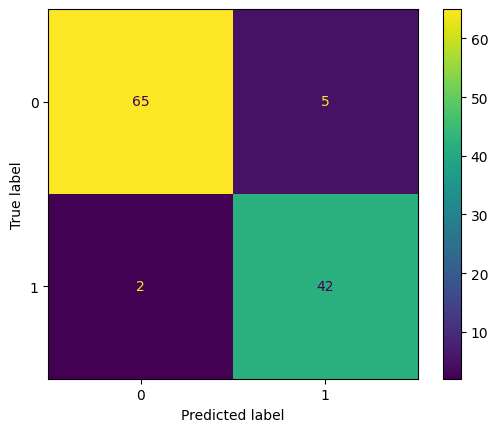

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_np, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

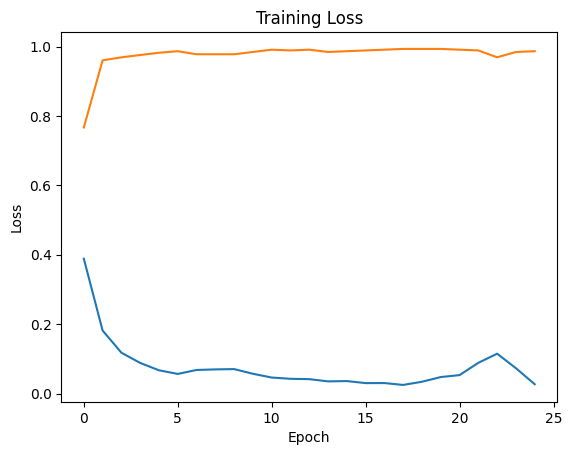

In [23]:
plt.plot(history)
plt.plot(history_accuracy)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()